# Clustering des joueurs

Objectif : créer des clusters simples à partir de la table `player` de Neon.

On part sur :

- `player_id` pour identifier le joueur ;
- `best_position` comme information de lecture ;
- les caractéristiques numériques SoFIFA détaillées pour décrire le profil ;
- pas de nom, pas de valeur de marché, pas d'overall, pas de potentiel dans le modèle.

On fait d'abord le clustering global sans dissocier les positions. Le nombre de clusters n'est pas fixé à la main : on teste plusieurs valeurs et on choisit un compromis avec la silhouette.

## 1. Setup

In [ ]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
from IPython.display import display

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

PROJECT_ROOT = Path.cwd()
SCHEMA = "public"
RANDOM_STATE = 42
K_RANGE = range(2, 13)

## 2. Connexion Neon

In [ ]:
def load_env_file(path: Path) -> dict[str, str]:
    values = {}

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")

    return values


def sqlalchemy_url(url: str) -> str:
    if url.startswith("postgres://"):
        return url.replace("postgres://", "postgresql+psycopg2://", 1)

    if url.startswith("postgresql://"):
        return url.replace("postgresql://", "postgresql+psycopg2://", 1)

    return url


env_path = PROJECT_ROOT / ".env"
if not env_path.exists():
    raise FileNotFoundError("Fichier .env introuvable.")

local_env = load_env_file(env_path)
DATABASE_URL = (
    os.environ.get("NEON_DATABASE_URL")
    or os.environ.get("DATABASE_URL")
    or os.environ.get("POSTGRES_URL")
    or local_env.get("NEON_DATABASE_URL")
    or local_env.get("DATABASE_URL")
    or local_env.get("POSTGRES_URL")
    or ""
)

if not DATABASE_URL:
    raise RuntimeError("Ajoute NEON_DATABASE_URL, DATABASE_URL ou POSTGRES_URL dans .env.")

engine = create_engine(sqlalchemy_url(DATABASE_URL), pool_pre_ping=True)
print("Connexion configuree")

Connexion configuree


## 3. Récupérer les joueurs

In [ ]:
players_df = pd.read_sql(
    f'''
    SELECT *
    FROM "{SCHEMA}"."player"
    ''',
    engine,
)

print(players_df.shape)
display(players_df.head())

(6705, 101)


,player_id,player_name,full_name,sofifa_name,player_aliases,date_of_birth,nationality,height_cm,weight_kg,preferred_foot,observed_positions,positions,best_position,club_name,club_league_name,club_position,sofifa_id,has_sofifa_profile,lineup_rows,match_count,team_count,first_match_date,last_match_date,transfermarkt_market_value_eur,transfermarkt_highest_market_value_eur,best_overall,overall_rating,potential,sofifa_market_value_raw,sofifa_wage_raw,skill_moves,weak_foot,international_reputation,body_type,real_face,sofifa_release_clause_raw,acceleration_type,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,pos_ls_rating,pos_st_rating,pos_rs_rating,pos_lw_rating,pos_lf_rating,pos_cf_rating,pos_rf_rating,pos_rw_rating,pos_lam_rating,pos_cam_rating,pos_ram_rating,pos_lm_rating,pos_lcm_rating,pos_cm_rating,pos_rcm_rating,pos_rm_rating,pos_lwb_rating,pos_ldm_rating,pos_cdm_rating,pos_rdm_rating,pos_rwb_rating,pos_lb_rating,pos_lcb_rating,pos_cb_rating,pos_rcb_rating,pos_rb_rating,pos_gk_rating,player_specialities_json,roles_json,playstyles_json
0,889193,AZ Jackson,Aziel Christopher Jackson,Aziel Jackson,AZ Jackson,2001-10-25,United States,175.0,68.0,Right,Left Winger,"CAM,CM,ST",CAM,Jagiellonia Białystok,Ekstraklasa,SUB,262094.0,1,6,6,1,2025-09-24,2025-12-18,NaN,NaN,66.0,64.0,71.0,€1.2M,€3K,3.0,3.0,1.0,Normal (170-185),No,€1.9M,Explosive,52.0,58.0,35.0,65.0,56.0,74.0,40.0,30.0,58.0,65.0,80.0,78.0,86.0,53.0,82.0,64.0,57.0,36.0,58.0,45.0,49.0,30.0,60.0,62.0,56.0,64.0,29.0,40.0,32.0,6.0,12.0,8.0,14.0,6.0,60.0,60.0,60.0,65.0,63.0,63.0,63.0,65.0,64.0,64.0,64.0,63.0,57.0,57.0,57.0,63.0,49.0,48.0,48.0,48.0,49.0,47.0,42.0,42.0,42.0,47.0,14.0,[],"[{""focus"": ""Attack"", ""name"": ""Shadow striker +...",[]
1,1122196,Aaron Bibout,None,None,Aaron Bibout,2004-09-09,Cameroon,193.0,NaN,None,Centre-Forward,None,None,KRC Genk,None,None,NaN,0,15,15,1,2025-08-28,2026-03-19,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
2,434207,Aaron Connolly,Aaron Anthony Connolly,Aaron Connolly,Aaron Connolly,2000-01-28,Republic of Ireland,175.0,73.0,Right,"Centre-Forward,Left Winger","ST,LM,CAM,LW",ST,Leyton Orient,League One,CAM,237286.0,1,4,4,1,2021-09-19,2021-10-23,3500000.0,7000000.0,70.0,68.0,72.0,€1.7M,€2K,3.0,3.0,1.0,Normal (170-185),Yes,€3.1M,Controlled explosive,54.0,69.0,65.0,63.0,68.0,68.0,62.0,43.0,45.0,68.0,77.0,73.0,78.0,68.0,78.0,70.0,75.0,67.0,62.0,68.0,68.0,21.0,70.0,58.0,60.0,63.0,25.0,23.0,20.0,12.0,8.0,12.0,13.0,12.0,68.0,68.0,68.0,67.0,68.0,68.0,68.0,67.0,66.0,66.0,66.0,65.0,58.0,58.0,58.0,65.0,49.0,46.0,46.0,46.0,49.0,46.0,43.0,43.0,43.0,46.0,18.0,[],"[{""focus"": ""Attack Support Versatile"", ""name"":...",[]
3,92571,Aaron Cresswell,Aaron William Cresswell,Aaron Cresswell,Aaron Cresswell,1989-12-15,England,175.0,66.0,Left,"Left-Back,Centre-Back","LB,CB,LM",LB,Stoke City,Championship,LB,189615.0,1,97,97,1,2021-08-15,2025-05-18,450000.0,12000000.0,72.0,72.0,72.0,€725K,€18K,2.0,3.0,1.0,Normal (170-185),Yes,€1.4M,Controlled,79.0,53.0,70.0,75.0,48.0,70.0,78.0,74.0,67.0,74.0,52.0,48.0,63.0,72.0,65.0,70.0,74.0,56.0,63.0,66.0,73.0,74.0,60.0,68.0,59.0,71.0,75.0,76.0,75.0,14.0,7.0,9.0,9.0,12.0,64.0,64.0,64.0,66.0,66.0,66.0,66.0,66.0,67.0,67.0,67.0,67.0,69.0,69.0,69.0,67.0,70.0,72.0,72.0,72.0,70.0,70.0,72.0,72.0,72.0,70.0,17.0,[],"[{""focus"": ""Defend Balanced Versatile"", ""name""...",[]
4,591949,Aaron Hickey,Aaron Buchanan Hickey,Aaron Hickey,Aaron 

## 4. Garder les caractéristiques utiles

In [ ]:
# Colonnes numériques utiles pour décrire un joueur.
# On évite les colonnes de valeur, overall, potentiel et les JSON.
feature_columns = [
    "height_cm",
    "weight_kg",
    "skill_moves",
    "weak_foot",
    "international_reputation",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "fk_accuracy",
    "long_passing",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "attack_position",
    "vision",
    "penalties",
    "composure",
    "defensive_awareness",
    "standing_tackle",
    "sliding_tackle",
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes",
]

base_columns = ["player_id", "best_position"]
missing_columns = [column for column in base_columns + feature_columns if column not in players_df.columns]

if missing_columns:
    raise KeyError(f"Colonnes absentes: {missing_columns}")

players_clustering_df = players_df[base_columns + feature_columns].copy()

for column in feature_columns:
    players_clustering_df[column] = pd.to_numeric(players_clustering_df[column], errors="coerce")

# On garde les joueurs qui ont au moins quelques vraies caractéristiques SoFIFA.
players_clustering_df = players_clustering_df.dropna(subset=feature_columns, how="all").reset_index(drop=True)

print(players_clustering_df.shape)
display(players_clustering_df.head())
players_clustering_df["best_position"].unique()

(6330, 41)


,player_id,best_position,height_cm,weight_kg,skill_moves,weak_foot,international_reputation,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,889193,CAM,175.0,68.0,3.0,3.0,1.0,52.0,58.0,35.0,65.0,56.0,74.0,40.0,30.0,58.0,65.0,80.0,78.0,86.0,53.0,82.0,64.0,57.0,36.0,58.0,45.0,49.0,30.0,60.0,62.0,56.0,64.0,29.0,40.0,32.0,6.0,12.0,8.0,14.0,6.0
1,1122196,None,193.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,434207,ST,175.0,73.0,3.0,3.0,1.0,54.0,69.0,65.0,63.0,68.0,68.0,62.0,43.0,45.0,68.0,77.0,73.0,78.0,68.0,78.0,70.0,75.0,67.0,62.0,68.0,68.0,21.0,70.0,58.0,60.0,63.0,25.0,23.0,20.0,12.0,8.0,12.0,13.0,12.0
3,92571,LB,175.0,66.0,2.0,3.0,1.0,79.0,53.0,70.0,75.0,48.0,70.0,78.0,74.0,67.0,74.0,52.0,48.0,63.0,72.0,65.0,70.0,74.0,56.0,63.0,66.0,73.0,74.0,60.0,68.0,59.0,71.0,75.0,76.0,75.0,14.0,7.0,9.0,9.0,12.0
4,591949,RB,185.0,72.0,2.0,5.0,1.0,74.0,48.0,67.0,75.0,67.0,74.0,61.0,40.0,68.0,74.0,70.0,72.0,71.0,73.0,64.0,68.0,69.0,60.0,59.0,60.0,78.0,72.0,59.0,67.0,47.0,72.0,75.0,76.0,75.0,13.0,14.0,8.0,13.0,5.0


array(['CAM', None, 'ST', 'LB', 'RB', 'CM', 'GK', 'CB', 'LW', 'RM', 'CDM',
       'LM', 'CF', 'RW', 'LWB', 'RWB'], dtype=object)

## 5. Vérifier les valeurs nulles

On regarde les valeurs manquantes, puis on retire les joueurs qui ont plus de 6 caractéristiques manquantes.

In [ ]:
# Vérification simple des valeurs nulles.
MAX_MISSING_VALUES = 6

players_clustering_df["missing_feature_count"] = players_clustering_df[feature_columns].isna().sum(axis=1)

missing_by_column_df = (
    players_clustering_df[feature_columns + ["best_position"]]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_by_column_df.columns = ["column", "missing_count"]
missing_by_column_df["missing_rate"] = (
    missing_by_column_df["missing_count"] / len(players_clustering_df)
).round(3)

players_many_missing_df = players_clustering_df[
    players_clustering_df["missing_feature_count"] > MAX_MISSING_VALUES
][["player_id", "best_position", "missing_feature_count"]]

print("Valeurs nulles par colonne")
display(missing_by_column_df)

print("Joueurs retires car trop de valeurs nulles:", len(players_many_missing_df))
display(players_many_missing_df.head())

players_clustering_clean_df = (
    players_clustering_df[players_clustering_df["missing_feature_count"] <= MAX_MISSING_VALUES]
    .drop(columns="missing_feature_count")
    .reset_index(drop=True)
)

print("Avant nettoyage:", players_clustering_df.shape)
print("Apres nettoyage:", players_clustering_clean_df.shape)

Valeurs nulles par colonne


,column,missing_count,missing_rate
0,defensive_awareness,1308,0.207
1,composure,1290,0.204
2,penalties,1284,0.203
3,stamina,1284,0.203
4,strength,1284,0.203
5,long_shots,1284,0.203
6,aggression,1284,0.203
7,interceptions,1284,0.203
8,attack_position,1284,0.203
9,vision,1284,0.203


Joueurs retires car trop de valeurs nulles: 1284


,player_id,best_position,missing_feature_count
1,1122196,None,38
5,974996,None,38
9,853239,None,38
10,1301102,None,38
11,9335,None,38


Avant nettoyage: (6330, 42)
Apres nettoyage: (5046, 41)


## 6. Préparer les données globales

On prépare une matrice numérique propre pour le clustering sans distinction de position.

In [ ]:
# X_global contient uniquement les caractéristiques numériques.
X_global = players_clustering_clean_df[feature_columns].copy()

preprocess_global = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_global_scaled = preprocess_global.fit_transform(X_global)

print(X_global_scaled.shape)

(5046, 39)


## 7. Choisir le nombre de clusters KMeans

On teste plusieurs nombres de clusters. L'inertie doit baisser, mais si elle baisse de moins en moins, ajouter des clusters devient moins utile. La silhouette aide à choisir un compromis.

In [ ]:
# Recherche simple des hyperparamètres principaux de KMeans.
# Le plus important ici est `n_clusters`. On compare aussi deux initialisations.
kmeans_results = []

for init_method in ["k-means++", "random"]:
    previous_inertia = None

    for k in K_RANGE:
        model = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=20,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_global_scaled)
        inertia_gain = None

        if previous_inertia is not None:
            inertia_gain = (previous_inertia - model.inertia_) / previous_inertia

        kmeans_results.append({
            "k": k,
            "init": init_method,
            "inertia": model.inertia_,
            "inertia_gain": inertia_gain,
            "silhouette": silhouette_score(X_global_scaled, labels),
        })
        previous_inertia = model.inertia_

kmeans_results_df = pd.DataFrame(kmeans_results)

best_kmeans_params = (
    kmeans_results_df
    .sort_values(["silhouette", "inertia_gain"], ascending=False)
    .iloc[0]
)

BEST_K = int(best_kmeans_params["k"])
BEST_INIT = best_kmeans_params["init"]

print("Meilleurs paramètres KMeans")
display(best_kmeans_params.to_frame().T)
display(kmeans_results_df.sort_values(["init", "k"]))

Meilleurs paramètres KMeans


,k,init,inertia,inertia_gain,silhouette
0,2,k-means++,110652.243623,NaN,0.569571


,k,init,inertia,inertia_gain,silhouette
0,2,k-means++,110652.243623,NaN,0.569571
1,3,k-means++,87027.812368,0.213502,0.252963
2,4,k-means++,74749.799434,0.141081,0.235404
3,5,k-means++,68376.470848,0.085262,0.230174
4,6,k-means++,63130.240911,0.076726,0.217347
5,7,k-means++,59846.476041,0.052016,0.202315
6,8,k-means++,57220.346275,0.043881,0.193639
7,9,k-means++,55009.465467,0.038638,0.188329
8,10,k-means++,53022.968368,0.036112,0.152735
9,11,k-means++,51468.304591,0.029321,0.152286


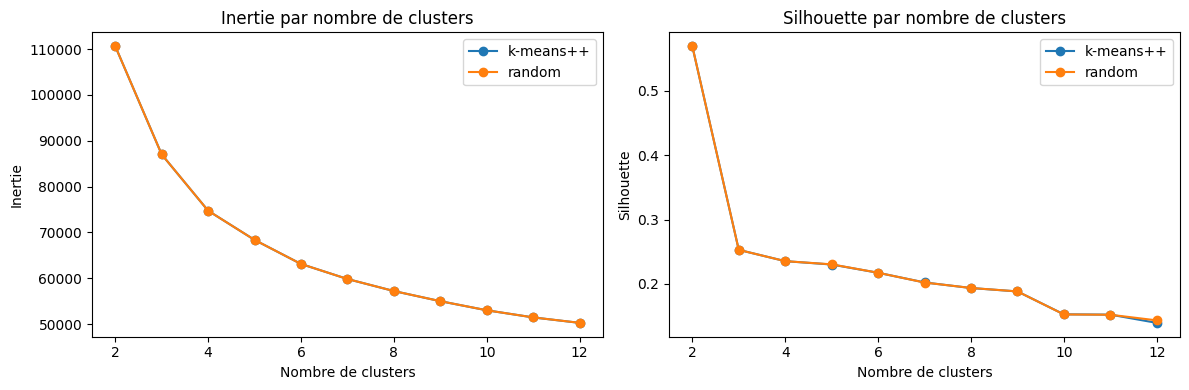

In [ ]:
# Visualisation du choix de k.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for init_method, init_results_df in kmeans_results_df.groupby("init"):
    axes[0].plot(init_results_df["k"], init_results_df["inertia"], marker="o", label=init_method)
    axes[1].plot(init_results_df["k"], init_results_df["silhouette"], marker="o", label=init_method)

axes[0].set_title("Inertie par nombre de clusters")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].set_title("Silhouette par nombre de clusters")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Clustering global KMeans

In [ ]:
# Clustering global avec les paramètres retenus.
kmeans_global = KMeans(
    n_clusters=BEST_K,
    init=BEST_INIT,
    n_init=20,
    random_state=RANDOM_STATE,
)

players_clusters_without_position_df = players_clustering_clean_df[["player_id", "best_position"]].copy()
players_clusters_without_position_df["cluster_kmeans"] = kmeans_global.fit_predict(X_global_scaled)

print(players_clusters_without_position_df["cluster_kmeans"].value_counts().sort_index())
display(players_clusters_without_position_df.head())

cluster_kmeans
0    4541
1     505
Name: count, dtype: int64


,player_id,best_position,cluster_kmeans
0,889193,CAM,0
1,434207,ST,0
2,92571,LB,0
3,591949,RB,0
4,123951,CM,0


## 9. Visualiser les joueurs en 2D

On projette les caractéristiques en deux dimensions avec une PCA pour voir la répartition globale des joueurs.

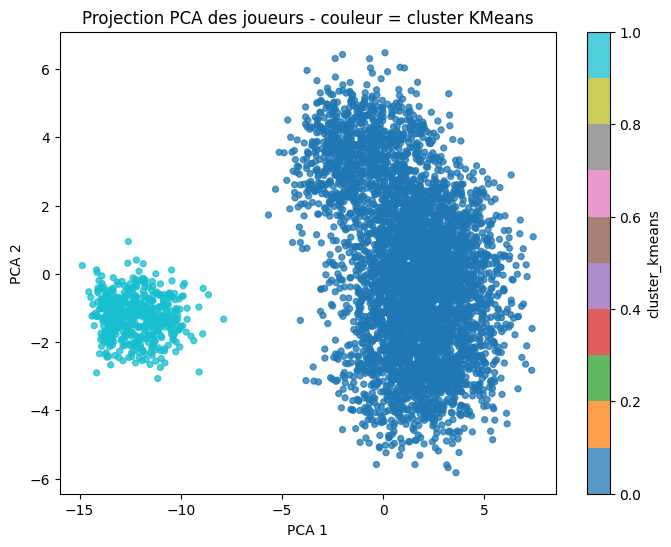

Variance expliquee par la PCA: [0.535 0.142]


,player_id,best_position,cluster_kmeans,pca_1,pca_2
0,889193,CAM,0,-0.247219,-3.166333
1,434207,ST,0,0.946544,-2.802094
2,92571,LB,0,2.238845,1.077068
3,591949,RB,0,2.106437,1.191163
4,123951,CM,0,3.763682,0.068380


In [ ]:
# La PCA sert uniquement à visualiser les joueurs en 2D.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
players_2d = pca.fit_transform(X_global_scaled)

players_2d_df = players_clusters_without_position_df.copy()
players_2d_df["pca_1"] = players_2d[:, 0]
players_2d_df["pca_2"] = players_2d[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    players_2d_df["pca_1"],
    players_2d_df["pca_2"],
    c=players_2d_df["cluster_kmeans"],
    cmap="tab10",
    s=18,
    alpha=0.75,
)
plt.title("Projection PCA des joueurs - couleur = cluster KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="cluster_kmeans")
plt.show()

print("Variance expliquee par la PCA:", pca.explained_variance_ratio_.round(3))
display(players_2d_df.head())

## 10. Comparer avec d'autres modèles globaux

On compare KMeans avec deux logiques différentes : clustering hiérarchique et Gaussian Mixture.

In [ ]:
# Deux autres modèles pour avoir un avis différent du KMeans.
agglomerative_global = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward")
gmm_global = GaussianMixture(
    n_components=BEST_K,
    covariance_type="full",
    n_init=5,
    random_state=RANDOM_STATE,
)

players_global_clusters_df = players_clusters_without_position_df.copy()
players_global_clusters_df["cluster_agglomerative"] = agglomerative_global.fit_predict(X_global_scaled)
players_global_clusters_df["cluster_gmm"] = gmm_global.fit_predict(X_global_scaled)

# La silhouette permet de comparer les modèles sur la séparation des groupes.
def safe_silhouette(labels):
    if pd.Series(labels).nunique() < 2:
        return None

    return silhouette_score(X_global_scaled, labels)

model_comparison_df = pd.DataFrame([
    {
        "model": "KMeans",
        "n_clusters": players_global_clusters_df["cluster_kmeans"].nunique(),
        "silhouette": safe_silhouette(players_global_clusters_df["cluster_kmeans"]),
    },
    {
        "model": "Agglomerative",
        "n_clusters": players_global_clusters_df["cluster_agglomerative"].nunique(),
        "silhouette": safe_silhouette(players_global_clusters_df["cluster_agglomerative"]),
    },
    {
        "model": "GaussianMixture",
        "n_clusters": players_global_clusters_df["cluster_gmm"].nunique(),
        "silhouette": safe_silhouette(players_global_clusters_df["cluster_gmm"]),
    },
])

cluster_sizes_df = pd.concat([
    players_global_clusters_df["cluster_kmeans"].value_counts().sort_index().rename("kmeans"),
    players_global_clusters_df["cluster_agglomerative"].value_counts().sort_index().rename("agglomerative"),
    players_global_clusters_df["cluster_gmm"].value_counts().sort_index().rename("gmm"),
], axis=1)

display(model_comparison_df)
display(cluster_sizes_df)
display(players_global_clusters_df.head())

,model,n_clusters,silhouette
0,KMeans,2,0.569571
1,Agglomerative,2,0.569571
2,GaussianMixture,2,0.569571


,kmeans,agglomerative,gmm
0,4541,4541,4541
1,505,505,505


,player_id,best_position,cluster_kmeans,cluster_agglomerative,cluster_gmm
0,889193,CAM,0,0,0
1,434207,ST,0,0,0
2,92571,LB,0,0,0
3,591949,RB,0,0,0
4,123951,CM,0,0,0


## Analyse globale

Résultat principal : le meilleur clustering global KMeans est `k = 2`.

Lecture : ce résultat est statistiquement propre, mais métier assez pauvre. Le modèle sépare surtout :

- cluster 0 : joueurs de champ, 4541 joueurs ;
- cluster 1 : gardiens, 505 joueurs.

La silhouette est élevée à `0.570` pour `k = 2`, puis baisse fortement : `0.253` à `k = 3`, `0.235` à `k = 4`, `0.230` à `k = 5`. Cela veut dire que la séparation gardiens / joueurs de champ domine toute la structure des données.

Les autres modèles testés donnent exactement la même séparation avec `k = 2` : KMeans, Agglomerative et GaussianMixture ont tous une silhouette de `0.570` et les mêmes tailles de clusters.

La PCA explique environ `67.7%` de la variance sur deux axes (`53.5%` + `14.2%`), donc la visualisation 2D est déjà assez informative.

Conclusion : pour un clustering utile de profils joueurs, il faudra probablement séparer les gardiens avant de chercher des profils plus fins chez les joueurs de champ. Le clustering global complet répond surtout à la question “gardien ou non gardien”, pas encore à “quel type de joueur de champ ?”.

## 11. Clustering joueurs de champ

On retire les gardiens, puis on refait la même logique sur les joueurs de champ uniquement. On retire aussi les caractéristiques gardien des features.

In [ ]:
# On retire les gardiens et les features spécifiques gardien.
gk_feature_columns = [
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes",
]

outfield_feature_columns = [
    column
    for column in feature_columns
    if column not in gk_feature_columns
]

players_outfield_df = (
    players_clustering_clean_df[players_clustering_clean_df["best_position"] != "GK"]
    .reset_index(drop=True)
    .copy()
)

X_outfield = players_outfield_df[outfield_feature_columns].copy()

preprocess_outfield = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_outfield_scaled = preprocess_outfield.fit_transform(X_outfield)

print("Joueurs de champ:", players_outfield_df.shape)
print("Features utilisees:", len(outfield_feature_columns))

Joueurs de champ: (4541, 41)
Features utilisees: 34


## 12. Choisir le nombre de clusters

In [ ]:
# On teste plusieurs k pour éviter de choisir un nombre de clusters au hasard.
outfield_kmeans_results = []

for init_method in ["k-means++", "random"]:
    previous_inertia = None

    for k in K_RANGE:
        model = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=20,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_outfield_scaled)
        inertia_gain = None

        if previous_inertia is not None:
            inertia_gain = (previous_inertia - model.inertia_) / previous_inertia

        outfield_kmeans_results.append({
            "k": k,
            "init": init_method,
            "inertia": model.inertia_,
            "inertia_gain": inertia_gain,
            "silhouette": silhouette_score(X_outfield_scaled, labels),
        })
        previous_inertia = model.inertia_

outfield_kmeans_results_df = pd.DataFrame(outfield_kmeans_results)

best_outfield_kmeans_params = (
    outfield_kmeans_results_df
    .sort_values(["silhouette", "inertia_gain"], ascending=False)
    .iloc[0]
)

BEST_K_OUTFIELD = int(best_outfield_kmeans_params["k"])
BEST_INIT_OUTFIELD = best_outfield_kmeans_params["init"]

print("Meilleurs paramètres KMeans joueurs de champ")
display(best_outfield_kmeans_params.to_frame().T)
display(outfield_kmeans_results_df.sort_values(["init", "k"]))

Meilleurs paramètres KMeans joueurs de champ


,k,init,inertia,inertia_gain,silhouette
0,2,k-means++,116586.08428,NaN,0.225602


,k,init,inertia,inertia_gain,silhouette
0,2,k-means++,116586.084280,NaN,0.225602
1,3,k-means++,98073.872997,0.158786,0.197302
2,4,k-means++,88761.187667,0.094956,0.172400
3,5,k-means++,81619.998786,0.080454,0.171696
4,6,k-means++,76994.019569,0.056677,0.153765
5,7,k-means++,72934.550724,0.052724,0.150410
6,8,k-means++,69594.166125,0.045800,0.146050
7,9,k-means++,67404.591348,0.031462,0.141034
8,10,k-means++,65443.924297,0.029088,0.133316
9,11,k-means++,63840.038220,0.024508,0.127359


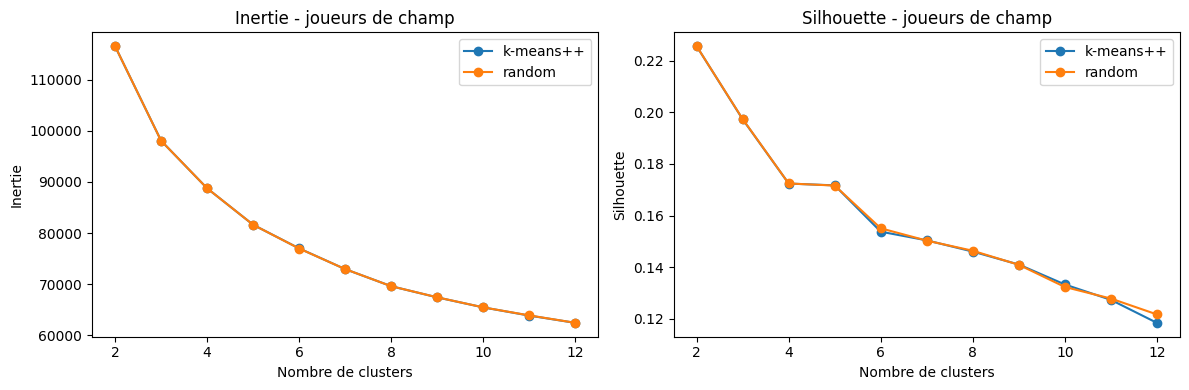

In [ ]:
# Graphes simples pour lire le choix de k.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for init_method, init_results_df in outfield_kmeans_results_df.groupby("init"):
    axes[0].plot(init_results_df["k"], init_results_df["inertia"], marker="o", label=init_method)
    axes[1].plot(init_results_df["k"], init_results_df["silhouette"], marker="o", label=init_method)

axes[0].set_title("Inertie - joueurs de champ")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].set_title("Silhouette - joueurs de champ")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Clustering KMeans joueurs de champ

In [ ]:
# Clustering final des joueurs de champ avec le meilleur k trouvé.
kmeans_outfield = KMeans(
    n_clusters=BEST_K_OUTFIELD,
    init=BEST_INIT_OUTFIELD,
    n_init=20,
    random_state=RANDOM_STATE,
)

players_outfield_clusters_df = players_outfield_df[["player_id", "best_position"]].copy()
players_outfield_clusters_df["cluster_kmeans_outfield"] = kmeans_outfield.fit_predict(X_outfield_scaled)

print(players_outfield_clusters_df["cluster_kmeans_outfield"].value_counts().sort_index())
display(players_outfield_clusters_df.head())

cluster_kmeans_outfield
0    3012
1    1529
Name: count, dtype: int64


,player_id,best_position,cluster_kmeans_outfield
0,889193,CAM,0
1,434207,ST,0
2,92571,LB,0
3,591949,RB,0
4,123951,CM,0


## 14. Visualiser les joueurs de champ

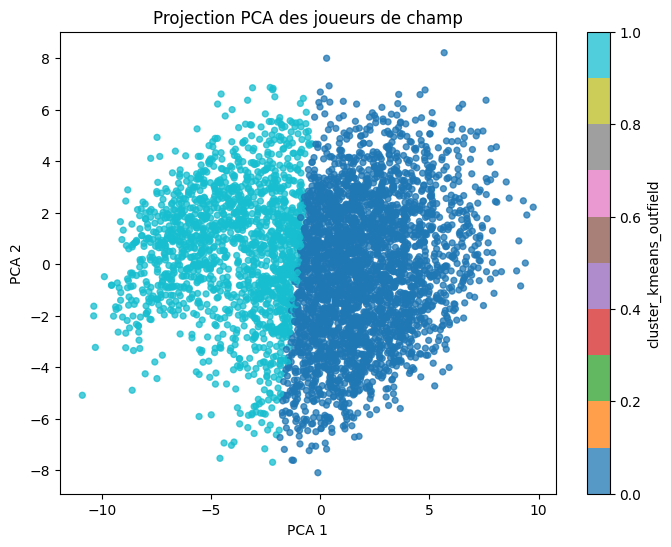

Variance expliquee par la PCA: [0.373 0.21 ]


,player_id,best_position,cluster_kmeans_outfield,pca_1,pca_2
0,889193,CAM,0,-0.372276,-5.208202
1,434207,ST,0,1.024373,-3.586716
2,92571,LB,0,0.525477,2.177606
3,591949,RB,0,0.224831,1.901377
4,123951,CM,0,3.069874,2.099507


In [ ]:
# PCA pour visualiser les joueurs de champ en 2D.
pca_outfield = PCA(n_components=2, random_state=RANDOM_STATE)
players_outfield_2d = pca_outfield.fit_transform(X_outfield_scaled)

players_outfield_2d_df = players_outfield_clusters_df.copy()
players_outfield_2d_df["pca_1"] = players_outfield_2d[:, 0]
players_outfield_2d_df["pca_2"] = players_outfield_2d[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    players_outfield_2d_df["pca_1"],
    players_outfield_2d_df["pca_2"],
    c=players_outfield_2d_df["cluster_kmeans_outfield"],
    cmap="tab10",
    s=18,
    alpha=0.75,
)
plt.title("Projection PCA des joueurs de champ")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="cluster_kmeans_outfield")
plt.show()

print("Variance expliquee par la PCA:", pca_outfield.explained_variance_ratio_.round(3))
display(players_outfield_2d_df.head())

## 15. Comparer avec deux autres modèles

In [ ]:
# Deux avis complémentaires : hiérarchique et mélange gaussien.
agglomerative_outfield = AgglomerativeClustering(n_clusters=BEST_K_OUTFIELD, linkage="ward")
gmm_outfield = GaussianMixture(
    n_components=BEST_K_OUTFIELD,
    covariance_type="full",
    n_init=5,
    random_state=RANDOM_STATE,
)

players_outfield_model_clusters_df = players_outfield_clusters_df.copy()
players_outfield_model_clusters_df["cluster_agglomerative_outfield"] = agglomerative_outfield.fit_predict(X_outfield_scaled)
players_outfield_model_clusters_df["cluster_gmm_outfield"] = gmm_outfield.fit_predict(X_outfield_scaled)

# Silhouette calculée sur le dataset joueurs de champ.
def safe_outfield_silhouette(labels):
    if pd.Series(labels).nunique() < 2:
        return None

    return silhouette_score(X_outfield_scaled, labels)

outfield_model_comparison_df = pd.DataFrame([
    {
        "model": "KMeans",
        "n_clusters": players_outfield_model_clusters_df["cluster_kmeans_outfield"].nunique(),
        "silhouette": safe_outfield_silhouette(players_outfield_model_clusters_df["cluster_kmeans_outfield"]),
    },
    {
        "model": "Agglomerative",
        "n_clusters": players_outfield_model_clusters_df["cluster_agglomerative_outfield"].nunique(),
        "silhouette": safe_outfield_silhouette(players_outfield_model_clusters_df["cluster_agglomerative_outfield"]),
    },
    {
        "model": "GaussianMixture",
        "n_clusters": players_outfield_model_clusters_df["cluster_gmm_outfield"].nunique(),
        "silhouette": safe_outfield_silhouette(players_outfield_model_clusters_df["cluster_gmm_outfield"]),
    },
])

outfield_cluster_sizes_df = pd.concat([
    players_outfield_model_clusters_df["cluster_kmeans_outfield"].value_counts().sort_index().rename("kmeans"),
    players_outfield_model_clusters_df["cluster_agglomerative_outfield"].value_counts().sort_index().rename("agglomerative"),
    players_outfield_model_clusters_df["cluster_gmm_outfield"].value_counts().sort_index().rename("gmm"),
], axis=1)

display(outfield_model_comparison_df)
display(outfield_cluster_sizes_df)
display(players_outfield_model_clusters_df.head())

,model,n_clusters,silhouette
0,KMeans,2,0.225602
1,Agglomerative,2,0.235569
2,GaussianMixture,2,0.172081


,kmeans,agglomerative,gmm
0,3012,3676,2188
1,1529,865,2353


,player_id,best_position,cluster_kmeans_outfield,cluster_agglomerative_outfield,cluster_gmm_outfield
0,889193,CAM,0,0,0
1,434207,ST,0,0,0
2,92571,LB,0,0,1
3,591949,RB,0,0,1
4,123951,CM,0,0,1


## 16. Checks rapides des clusters

In [ ]:
# Check 1 : quelles positions réelles composent chaque cluster ?
outfield_cluster_position_counts_df = pd.crosstab(
    players_outfield_clusters_df["cluster_kmeans_outfield"],
    players_outfield_clusters_df["best_position"],
)

outfield_cluster_position_rates_df = pd.crosstab(
    players_outfield_clusters_df["cluster_kmeans_outfield"],
    players_outfield_clusters_df["best_position"],
    normalize="index",
).round(3)

# Check 2 : positions dominantes par cluster.
top_positions_by_outfield_cluster_df = (
    players_outfield_clusters_df
    .groupby("cluster_kmeans_outfield")["best_position"]
    .value_counts(normalize=True)
    .rename("position_rate")
    .reset_index()
    .sort_values(["cluster_kmeans_outfield", "position_rate"], ascending=[True, False])
    .groupby("cluster_kmeans_outfield")
    .head(3)
)

# Check 3 : profil moyen simple de chaque cluster.
outfield_profile_groups = {
    "pace": ["sprint_speed", "acceleration"],
    "shooting": ["finishing", "attack_position", "shot_power", "long_shots", "penalties", "volleys"],
    "passing": ["vision", "crossing", "fk_accuracy", "long_passing", "short_passing", "curve"],
    "dribbling": ["agility", "balance", "reactions", "composure", "ball_control", "dribbling"],
    "defending": ["interceptions", "heading_accuracy", "defensive_awareness", "standing_tackle", "sliding_tackle"],
    "physical": ["jumping", "stamina", "strength", "aggression"],
}

outfield_cluster_profiles_df = players_outfield_df[["player_id"]].copy()
outfield_cluster_profiles_df = outfield_cluster_profiles_df.merge(
    players_outfield_clusters_df[["player_id", "cluster_kmeans_outfield"]],
    on="player_id",
    how="left",
)

for group_name, columns in outfield_profile_groups.items():
    outfield_cluster_profiles_df[group_name] = players_outfield_df[columns].mean(axis=1)

outfield_cluster_profile_summary_df = (
    outfield_cluster_profiles_df
    .groupby("cluster_kmeans_outfield")
    [list(outfield_profile_groups.keys())]
    .mean()
    .round(1)
)

outfield_cluster_profile_summary_df.insert(
    0,
    "player_count",
    players_outfield_clusters_df["cluster_kmeans_outfield"].value_counts().sort_index(),
)

display(outfield_cluster_position_counts_df)
display(outfield_cluster_position_rates_df)
display(top_positions_by_outfield_cluster_df)
display(outfield_cluster_profile_summary_df)

best_position,CAM,CB,CDM,CF,CM,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
cluster_kmeans_outfield,,,,,,,,,,,,,,
0,725,80,219,24,363,142,219,56,28,151,310,78,33,584
1,39,918,139,0,42,97,8,0,32,92,24,1,31,106


best_position,CAM,CB,CDM,CF,CM,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
cluster_kmeans_outfield,,,,,,,,,,,,,,
0,0.241,0.027,0.073,0.008,0.121,0.047,0.073,0.019,0.009,0.05,0.103,0.026,0.011,0.194
1,0.026,0.600,0.091,0.000,0.027,0.063,0.005,0.000,0.021,0.06,0.016,0.001,0.020,0.069


,cluster_kmeans_outfield,best_position,position_rate
0,0,CAM,0.240704
1,0,ST,0.193891
2,0,CM,0.120518
14,1,CB,0.600392
15,1,CDM,0.090909
16,1,ST,0.069326


,player_count,pace,shooting,passing,dribbling,defending,physical
cluster_kmeans_outfield,,,,,,,
0,3012,73.1,65.9,66.4,72.6,52.6,67.8
1,1529,64.8,44.3,52.0,61.5,64.7,70.4


## Analyse joueurs de champ

Sur les joueurs de champ, le meilleur KMeans reste `k = 2`, avec une silhouette de `0.226`. La séparation est moins nette que le split global gardiens / non-gardiens, mais elle commence à être utile métier.

Lecture des deux clusters KMeans :

- cluster 0 : 3012 joueurs, profil plutôt offensif / technique ; positions dominantes `CAM`, `ST`, `CM`, `RM` ; profil moyen plus fort en vitesse, tir, passe et dribble.
- cluster 1 : 1529 joueurs, profil plutôt défensif / physique ; position dominante `CB` à environ 60% ; profil moyen plus fort en défense et physique.

Comparaison modèles :

- Agglomerative : silhouette `0.236`, légèrement meilleur que KMeans.
- KMeans : silhouette `0.226`, plus simple et lisible.
- GaussianMixture : silhouette `0.172`, moins convaincant ici.

La PCA 2D explique environ `58.3%` de la variance (`37.3%` + `21.0%`). La projection est donc utile pour lire la structure, mais moins dominante que dans le cas global avec gardiens.

Conclusion : pour une première lecture, on a deux grands rôles : offensif/technique contre défensif/physique. Pour obtenir des profils plus fins, il faudra accepter une silhouette plus basse et tester `k = 4` ou `k = 5`, ou bien clusteriser par grandes familles de postes.

## 17. Clustering par role

On regroupe les postes en rôles larges, puis on fait un clustering séparé dans chaque rôle.

In [ ]:
# Mapping simple : poste SoFIFA principal -> rôle large.
position_to_role = {
    "CB": "central_defender",
    "LB": "fullback_wingback",
    "RB": "fullback_wingback",
    "LWB": "fullback_wingback",
    "RWB": "fullback_wingback",
    "CDM": "defensive_midfielder",
    "CM": "central_midfielder",
    "CAM": "attacking_midfielder",
    "LM": "wide_player",
    "RM": "wide_player",
    "LW": "wide_player",
    "RW": "wide_player",
    "ST": "forward",
    "CF": "forward",
}

players_by_role_df = players_outfield_df.copy()
players_by_role_df["player_role"] = players_by_role_df["best_position"].map(position_to_role)
players_by_role_df = players_by_role_df.dropna(subset=["player_role"]).reset_index(drop=True)

role_position_counts_df = pd.crosstab(
    players_by_role_df["player_role"],
    players_by_role_df["best_position"],
)

print(players_by_role_df.shape)
display(role_position_counts_df)

(4541, 42)


best_position,CAM,CB,CDM,CF,CM,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
player_role,,,,,,,,,,,,,,
attacking_midfielder,764,0,0,0,0,0,0,0,0,0,0,0,0,0
central_defender,0,998,0,0,0,0,0,0,0,0,0,0,0,0
central_midfielder,0,0,0,0,405,0,0,0,0,0,0,0,0,0
defensive_midfielder,0,0,358,0,0,0,0,0,0,0,0,0,0,0
forward,0,0,0,24,0,0,0,0,0,0,0,0,0,690
fullback_wingback,0,0,0,0,0,239,0,0,60,243,0,0,64,0
wide_player,0,0,0,0,0,0,227,56,0,0,334,79,0,0


## 18. Choisir KMeans par role

Pour chaque rôle, on teste un range de `k`. Le meilleur `k` est choisi séparément pour chaque groupe avec la silhouette.

In [ ]:
# Pour chaque rôle, on teste plusieurs k et on garde celui avec la meilleure silhouette.
MIN_PLAYERS_BY_ROLE = 30
ROLE_K_RANGE = range(2, 9)

role_kmeans_results = []
role_clustered_players = []
skipped_roles = []

for role, role_players_df in players_by_role_df.groupby("player_role"):
    role_players_df = role_players_df.reset_index(drop=True)
    player_count = len(role_players_df)

    if player_count < MIN_PLAYERS_BY_ROLE:
        skipped_roles.append({
            "player_role": role,
            "player_count": player_count,
            "reason": "pas assez de joueurs",
        })
        continue

    X_role = role_players_df[outfield_feature_columns].copy()

    role_preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    X_role_scaled = role_preprocess.fit_transform(X_role)

    # On adapte le range si un rôle contient moins de joueurs que prévu.
    candidate_k_values = [k for k in ROLE_K_RANGE if k < player_count]

    if not candidate_k_values:
        skipped_roles.append({
            "player_role": role,
            "player_count": player_count,
            "reason": "aucun k possible",
        })
        continue

    role_results = []
    previous_inertia = None

    for k in candidate_k_values:
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_role_scaled)
        inertia_gain = None

        if previous_inertia is not None:
            inertia_gain = (previous_inertia - model.inertia_) / previous_inertia

        role_results.append({
            "player_role": role,
            "k": k,
            "player_count": player_count,
            "inertia": model.inertia_,
            "inertia_gain": inertia_gain,
            "silhouette": silhouette_score(X_role_scaled, labels),
        })
        previous_inertia = model.inertia_

    role_results_df = pd.DataFrame(role_results)
    best_role_params = role_results_df.sort_values("silhouette", ascending=False).iloc[0]
    best_k_role = int(best_role_params["k"])

    final_model = KMeans(
        n_clusters=best_k_role,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    role_output_df = role_players_df[["player_id", "best_position", "player_role"]].copy()
    role_output_df["cluster_by_role"] = final_model.fit_predict(X_role_scaled)
    role_output_df["role_cluster_id"] = (
        role_output_df["player_role"]
        + "_"
        + role_output_df["cluster_by_role"].astype(str)
    )

    role_kmeans_results.extend(role_results)
    role_clustered_players.append(role_output_df)

role_kmeans_results_df = pd.DataFrame(role_kmeans_results)
players_clusters_by_role_df = pd.concat(role_clustered_players, ignore_index=True)
skipped_roles_df = pd.DataFrame(skipped_roles)

best_k_by_role_df = (
    role_kmeans_results_df
    .sort_values(["player_role", "silhouette"], ascending=[True, False])
    .groupby("player_role")
    .head(1)
    .reset_index(drop=True)
)

print(players_clusters_by_role_df.shape)
display(best_k_by_role_df)
display(role_kmeans_results_df.sort_values(["player_role", "k"]))
display(skipped_roles_df)

(4541, 5)


,player_role,k,player_count,inertia,inertia_gain,silhouette
0,attacking_midfielder,2,764,18971.329902,NaN,0.218780
1,central_defender,2,998,25098.206947,NaN,0.220961
2,central_midfielder,2,405,9940.898617,NaN,0.224084
3,defensive_midfielder,2,358,8611.539475,NaN,0.234456
4,forward,2,714,17573.396607,NaN,0.229988
5,fullback_wingback,2,606,14380.302223,NaN,0.241129
6,wide_player,2,696,17763.155343,NaN,0.206527


,player_role,k,player_count,inertia,inertia_gain,silhouette
0,attacking_midfielder,2,764,18971.329902,NaN,0.218780
1,attacking_midfielder,3,764,17005.955040,0.103597,0.147500
2,attacking_midfielder,4,764,15455.352035,0.091180,0.144382
3,attacking_midfielder,5,764,14541.807330,0.059109,0.131643
4,attacking_midfielder,6,764,13922.919690,0.042559,0.124060
5,attacking_midfielder,7,764,13296.823799,0.044969,0.117256
6,attacking_midfielder,8,764,12841.811969,0.034220,0.114779
7,central_defender,2,998,25098.206947,NaN,0.220961
8,central_defender,3,998,22578.854467,0.100380,0.137585
9,central_defender,4,998,20793.922782,0.079053,0.135925


""


## 19. Graphes de choix de k par role

Chaque ligne correspond à un rôle. À gauche : inertie. À droite : silhouette.

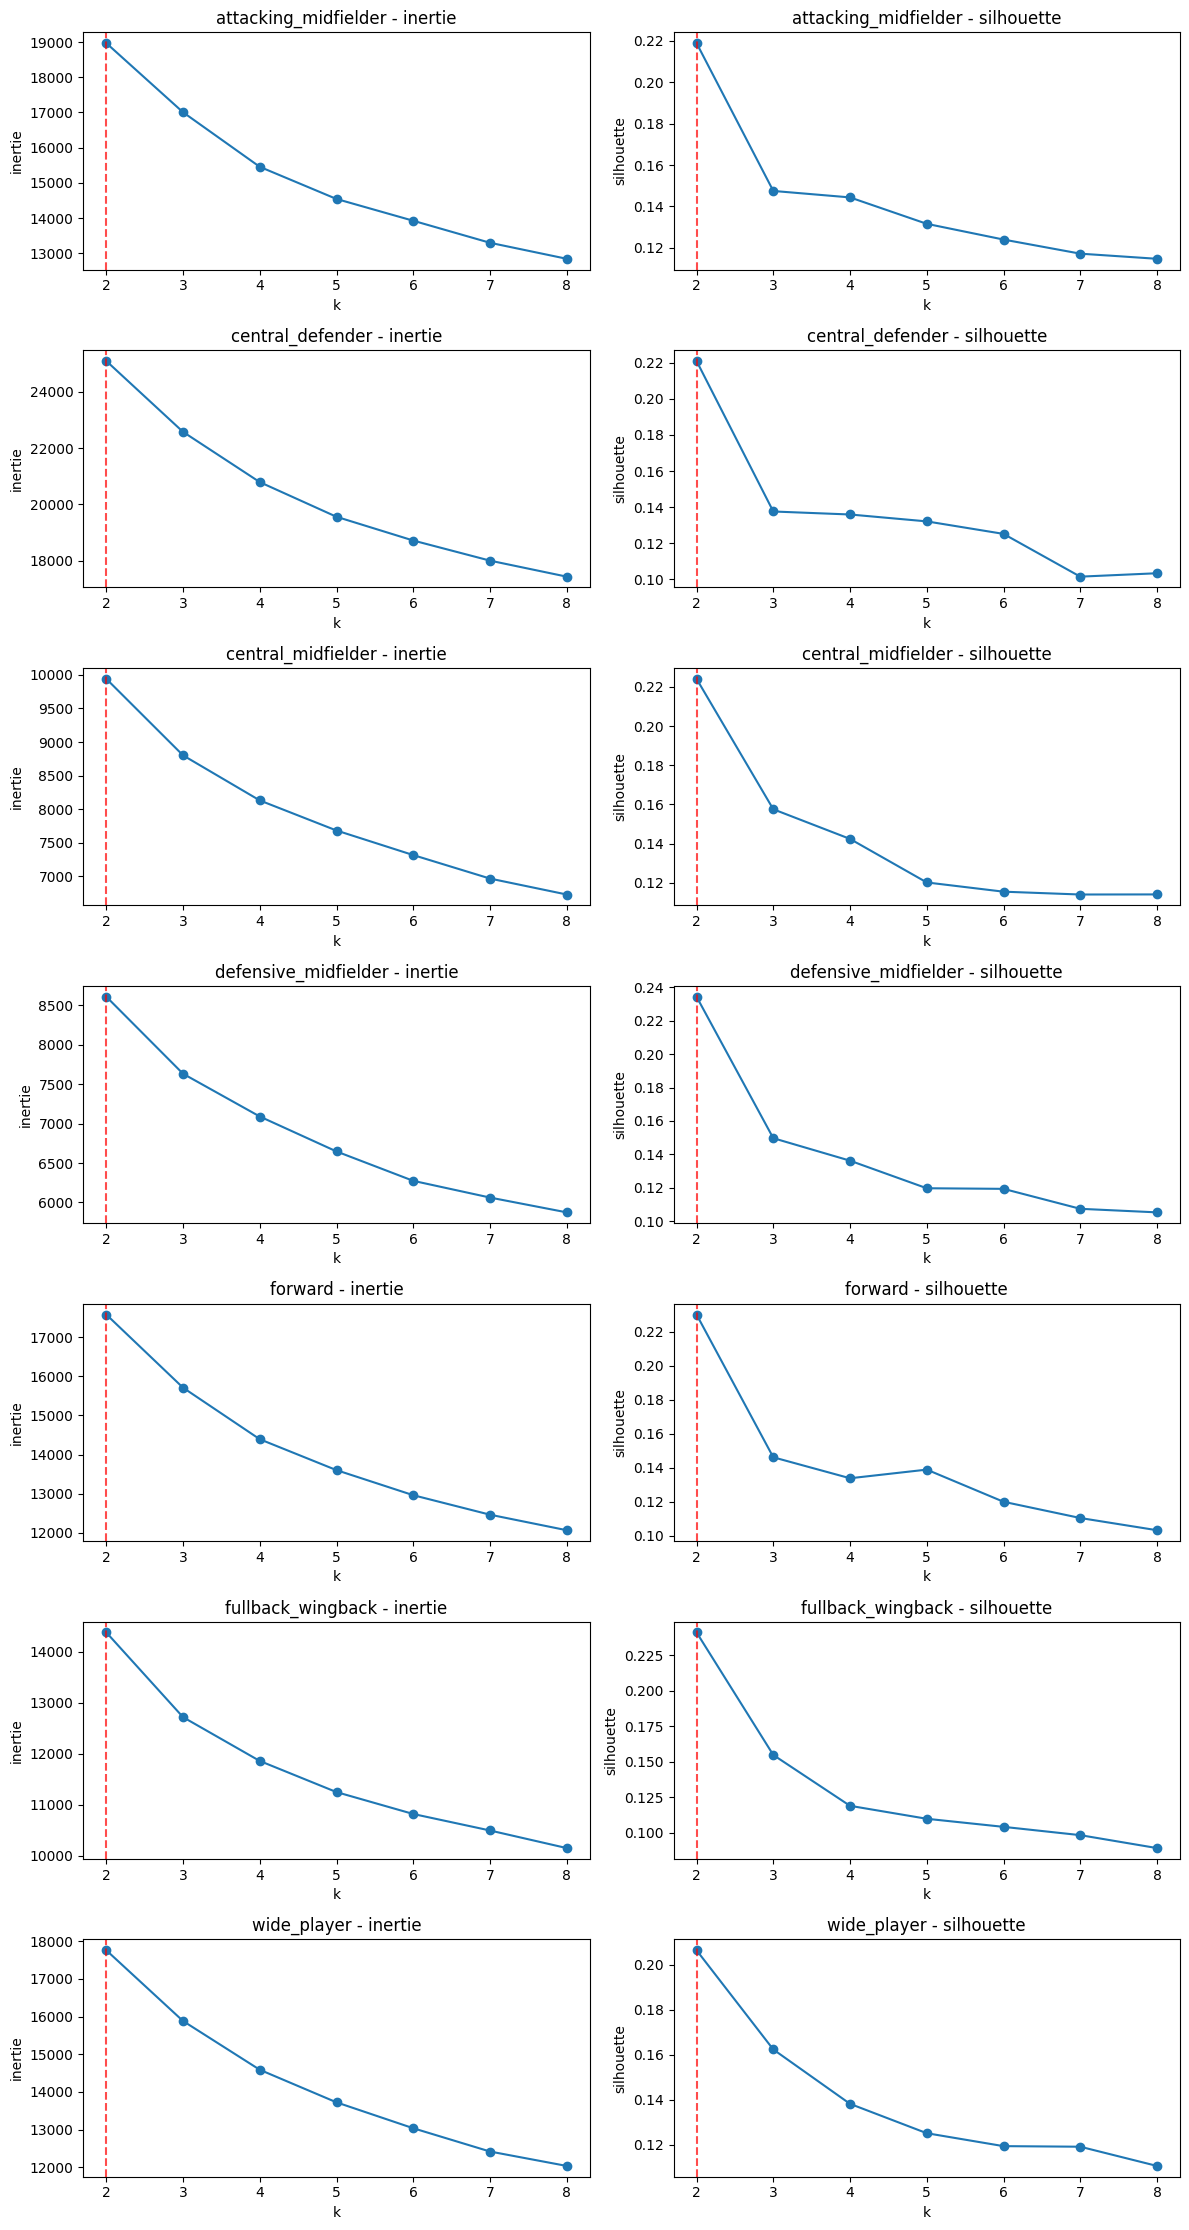

In [ ]:
# Graphes de sélection de k pour tous les rôles.
roles_to_plot = sorted(role_kmeans_results_df["player_role"].unique())
fig, axes = plt.subplots(
    nrows=len(roles_to_plot),
    ncols=2,
    figsize=(12, 3.2 * len(roles_to_plot)),
)

if len(roles_to_plot) == 1:
    axes = [axes]

for row_index, role in enumerate(roles_to_plot):
    role_results_df = role_kmeans_results_df[role_kmeans_results_df["player_role"] == role]
    best_role_row = best_k_by_role_df[best_k_by_role_df["player_role"] == role].iloc[0]
    best_k = int(best_role_row["k"])

    axes[row_index][0].plot(role_results_df["k"], role_results_df["inertia"], marker="o")
    axes[row_index][0].axvline(best_k, linestyle="--", color="red", alpha=0.7)
    axes[row_index][0].set_title(f"{role} - inertie")
    axes[row_index][0].set_xlabel("k")
    axes[row_index][0].set_ylabel("inertie")

    axes[row_index][1].plot(role_results_df["k"], role_results_df["silhouette"], marker="o")
    axes[row_index][1].axvline(best_k, linestyle="--", color="red", alpha=0.7)
    axes[row_index][1].set_title(f"{role} - silhouette")
    axes[row_index][1].set_xlabel("k")
    axes[row_index][1].set_ylabel("silhouette")

plt.tight_layout()
plt.show()

## 20. Checks rapides par role

In [ ]:
# Check 1 : taille des clusters dans chaque rôle.
role_cluster_sizes_df = (
    players_clusters_by_role_df
    .groupby(["player_role", "cluster_by_role"])
    .size()
    .reset_index(name="player_count")
    .sort_values(["player_role", "cluster_by_role"])
)

# Check 2 : positions réelles dominantes dans chaque cluster de rôle.
top_positions_by_role_cluster_df = (
    players_clusters_by_role_df
    .groupby(["player_role", "cluster_by_role"])["best_position"]
    .value_counts(normalize=True)
    .rename("position_rate")
    .reset_index()
    .sort_values(["player_role", "cluster_by_role", "position_rate"], ascending=[True, True, False])
    .groupby(["player_role", "cluster_by_role"])
    .head(2)
)

# Check 3 : profil moyen de chaque cluster.
role_profile_groups = {
    "pace": ["sprint_speed", "acceleration"],
    "shooting": ["finishing", "attack_position", "shot_power", "long_shots", "penalties", "volleys"],
    "passing": ["vision", "crossing", "fk_accuracy", "long_passing", "short_passing", "curve"],
    "dribbling": ["agility", "balance", "reactions", "composure", "ball_control", "dribbling"],
    "defending": ["interceptions", "heading_accuracy", "defensive_awareness", "standing_tackle", "sliding_tackle"],
    "physical": ["jumping", "stamina", "strength", "aggression"],
}

role_feature_columns = sorted({
    column
    for columns in role_profile_groups.values()
    for column in columns
})

role_cluster_profiles_df = players_clusters_by_role_df.merge(
    players_by_role_df[["player_id"] + role_feature_columns],
    on="player_id",
    how="left",
)

for group_name, columns in role_profile_groups.items():
    role_cluster_profiles_df[group_name] = role_cluster_profiles_df[columns].mean(axis=1)

role_cluster_profile_summary_df = (
    role_cluster_profiles_df
    .groupby(["player_role", "cluster_by_role"])
    [list(role_profile_groups.keys())]
    .mean()
    .round(1)
    .reset_index()
)

role_cluster_profile_summary_df = role_cluster_profile_summary_df.merge(
    role_cluster_sizes_df,
    on=["player_role", "cluster_by_role"],
    how="left",
)

ordered_columns = ["player_role", "cluster_by_role", "player_count"] + list(role_profile_groups.keys())
role_cluster_profile_summary_df = role_cluster_profile_summary_df[ordered_columns]

display(role_cluster_sizes_df)
display(top_positions_by_role_cluster_df)
display(role_cluster_profile_summary_df)

,player_role,cluster_by_role,player_count
0,attacking_midfielder,0,384
1,attacking_midfielder,1,380
2,central_defender,0,430
3,central_defender,1,568
4,central_midfielder,0,197
5,central_midfielder,1,208
6,defensive_midfielder,0,185
7,defensive_midfielder,1,173
8,forward,0,322
9,forward,1,392


,player_role,cluster_by_role,best_position,position_rate
0,attacking_midfielder,0,CAM,1.000000
1,attacking_midfielder,1,CAM,1.000000
2,central_defender,0,CB,1.000000
3,central_defender,1,CB,1.000000
4,central_midfielder,0,CM,1.000000
5,central_midfielder,1,CM,1.000000
6,defensive_midfielder,0,CDM,1.000000
7,defensive_midfielder,1,CDM,1.000000
8,forward,0,ST,0.934783
9,forward,0,CF,0.065217


,player_role,cluster_by_role,player_count,pace,shooting,passing,dribbling,defending,physical
0,attacking_midfielder,0,384,73.0,71.7,73.8,77.3,51.2,65.3
1,attacking_midfielder,1,380,72.0,59.5,61.4,69.1,43.2,56.7
2,central_defender,0,430,66.3,49.1,59.0,66.8,76.1,77.5
3,central_defender,1,568,60.1,36.8,46.1,57.0,67.3,70.8
4,central_midfielder,0,197,63.6,59.2,64.7,68.7,62.6,68.2
5,central_midfielder,1,208,63.8,70.6,75.5,76.4,70.0,72.9
6,defensive_midfielder,0,185,62.0,63.8,70.0,73.0,73.6,75.7
7,defensive_midfielder,1,173,62.8,51.6,58.6,65.2,64.5,69.0
8,forward,0,322,73.6,75.5,65.2,73.4,43.5,74.4
9,forward,1,392,70.7,65.3,52.3,64.3,32.9,67.6


## 21. Controle : fort/faible ou vrais profils ?

Hypothèse à vérifier : les clusters ne décrivent peut-être pas des styles de joueurs, mais seulement un axe général `fort vs faible`.

On regarde donc simplement :

- la distribution des features sans gardiens ;
- les centres de clusters ;
- les écarts entre centres.

Si un cluster est supérieur sur presque toutes les features, on capte surtout le niveau global. Si les écarts sont ciblés sur certaines features, on capte plutôt des profils.

,mean,std,min,25%,50%,75%,max,iqr
sliding_tackle,54.0,19.7,10.0,36.0,61.0,70.0,89.0,34.0
interceptions,55.7,19.6,11.0,38.0,63.0,71.0,91.0,33.0
standing_tackle,57.0,19.3,10.0,40.0,64.0,72.0,91.0,32.0
defensive_awareness,55.2,18.8,10.0,39.0,61.0,70.0,91.0,31.0
volleys,52.9,15.4,12.0,41.0,55.0,65.0,92.0,24.0
finishing,57.2,16.3,15.0,46.0,61.0,69.0,94.0,23.0
fk_accuracy,51.6,15.0,15.0,40.0,51.0,63.0,93.0,23.0
curve,59.7,14.5,20.0,51.0,62.0,71.0,93.0,20.0
penalties,55.5,13.0,20.0,45.0,55.0,65.0,93.0,20.0
long_shots,58.0,15.6,15.0,49.0,62.0,69.0,91.0,20.0


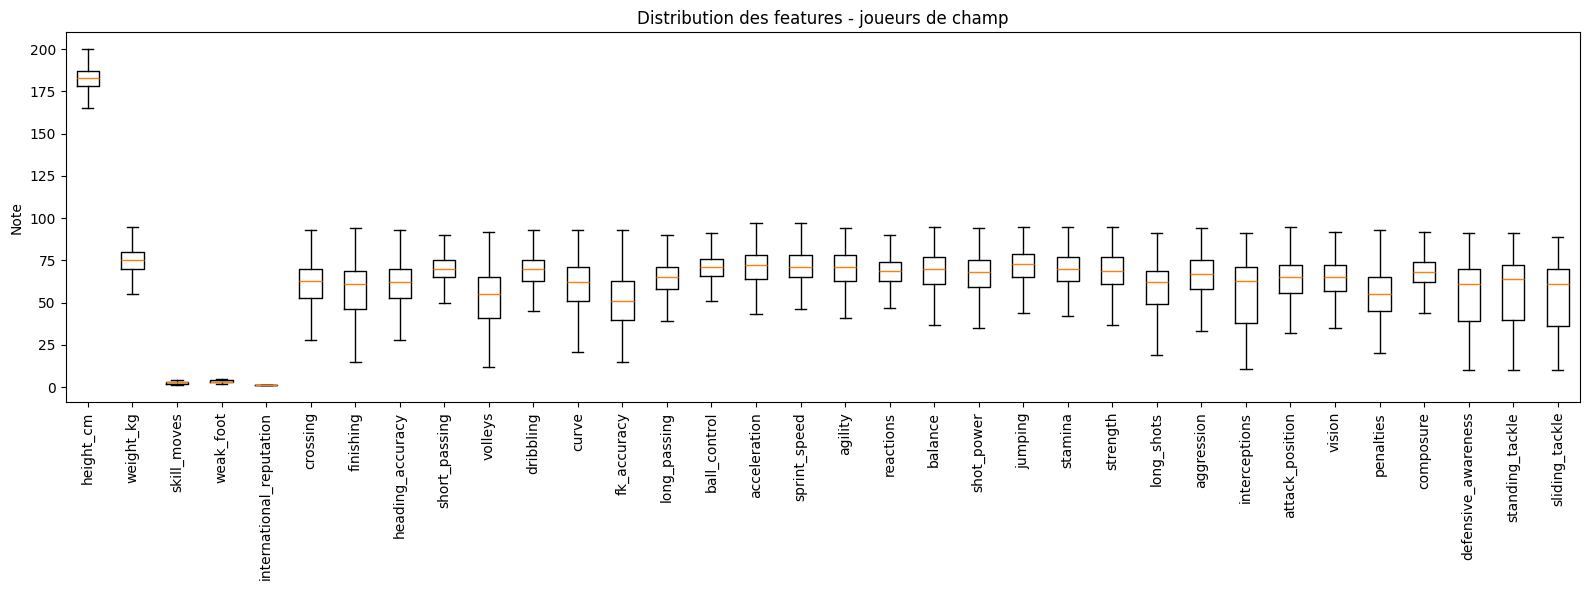

,cluster_rate
cluster_kmeans_outfield,
0,0.663
1,0.337


,height_cm,weight_kg,skill_moves,weak_foot,international_reputation,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle
cluster_kmeans_outfield,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,180.1,73.5,3.1,3.2,1.4,65.8,66.0,59.5,71.9,60.7,73.2,66.9,58.5,65.9,74.0,73.6,72.5,74.4,70.5,72.9,71.4,70.8,71.0,65.7,66.2,63.6,51.3,69.8,69.2,61.2,70.7,50.8,52.5,49.0
1,185.9,78.6,2.2,2.9,1.2,49.7,39.9,65.3,65.5,37.5,58.1,45.7,38.0,60.6,63.7,63.5,66.1,59.6,65.5,59.5,55.4,73.4,66.4,73.3,41.9,68.4,64.2,47.1,52.6,44.2,62.5,64.0,66.1,63.9


,mean_all_features,positive_feature_rate_vs_global
cluster_kmeans_outfield,,
0,63.8,0.71
1,57.4,0.29


,min_center,max_center,gap,best_cluster
finishing,39.9,66.0,26.1,0
long_shots,41.9,66.2,24.3,0
volleys,37.5,60.7,23.2,0
attack_position,47.1,69.8,22.7,0
curve,45.7,66.9,21.2,0
fk_accuracy,38.0,58.5,20.5,0
penalties,44.2,61.2,17.0,0
vision,52.6,69.2,16.6,0
crossing,49.7,65.8,16.1,0
shot_power,55.4,71.4,16.0,0


,player_role,cluster_by_role,mean_all_features,player_count
0,attacking_midfielder,0,66.5,384
1,attacking_midfielder,1,58.3,380
2,central_defender,0,63.2,430
3,central_defender,1,54.5,568
4,central_midfielder,0,62.7,197
5,central_midfielder,1,69.7,208
6,defensive_midfielder,0,67.7,185
7,defensive_midfielder,1,60.0,173
8,forward,0,65.2,322
9,forward,1,57.0,392


,min,max,gap
player_role,,,
central_defender,54.5,63.2,8.7
fullback_wingback,58.4,66.7,8.3
attacking_midfielder,58.3,66.5,8.2
forward,57.0,65.2,8.2
defensive_midfielder,60.0,67.7,7.7
wide_player,58.5,66.1,7.6
central_midfielder,62.7,69.7,7.0


,mean_feature_gap,max_feature_gap
player_role,,
central_defender,8.7,15.6
forward,8.3,14.7
fullback_wingback,8.3,15.6
attacking_midfielder,8.2,14.9
defensive_midfielder,7.8,14.9
wide_player,7.7,13.4
central_midfielder,7.1,13.6


In [ ]:
# 1. Distribution globale des features, sans gardiens.
# C'est notre lecture type candles : min, quartiles, médiane, moyenne, max.
outfield_feature_candles_df = (
    players_outfield_df[outfield_feature_columns]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(1)
)

outfield_feature_candles_df["iqr"] = (
    outfield_feature_candles_df["75%"] - outfield_feature_candles_df["25%"]
).round(1)

outfield_feature_candles_df = outfield_feature_candles_df.sort_values("iqr", ascending=False)

display(outfield_feature_candles_df)

plt.figure(figsize=(16, 6))
plt.boxplot(
    [players_outfield_df[column].dropna() for column in outfield_feature_columns],
    showfliers=False,
)
plt.xticks(
    range(1, len(outfield_feature_columns) + 1),
    outfield_feature_columns,
    rotation=90,
)
plt.title("Distribution des features - joueurs de champ")
plt.ylabel("Note")
plt.tight_layout()
plt.show()

# 2. Centres des clusters KMeans joueurs de champ.
outfield_cluster_features_df = players_outfield_clusters_df.merge(
    players_outfield_df[["player_id"] + outfield_feature_columns],
    on="player_id",
    how="left",
)

outfield_cluster_centers_df = (
    outfield_cluster_features_df
    .groupby("cluster_kmeans_outfield")[outfield_feature_columns]
    .mean()
    .round(1)
)

outfield_cluster_sizes_df = (
    players_outfield_clusters_df["cluster_kmeans_outfield"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("cluster_rate")
    .to_frame()
    .round(3)
)

outfield_global_feature_mean = players_outfield_df[outfield_feature_columns].mean()

outfield_cluster_level_df = outfield_cluster_centers_df.copy()
outfield_cluster_level_df["mean_all_features"] = outfield_cluster_centers_df.mean(axis=1).round(1)
outfield_cluster_level_df["positive_feature_rate_vs_global"] = (
    outfield_cluster_centers_df > outfield_global_feature_mean
).mean(axis=1).round(2)

# Ecart entre les centres de clusters, feature par feature.
outfield_cluster_center_diff_df = pd.DataFrame({
    "min_center": outfield_cluster_centers_df.min(axis=0),
    "max_center": outfield_cluster_centers_df.max(axis=0),
})
outfield_cluster_center_diff_df["gap"] = (
    outfield_cluster_center_diff_df["max_center"]
    - outfield_cluster_center_diff_df["min_center"]
).round(1)
outfield_cluster_center_diff_df["best_cluster"] = outfield_cluster_centers_df.idxmax(axis=0)
outfield_cluster_center_diff_df = outfield_cluster_center_diff_df.sort_values("gap", ascending=False)

display(outfield_cluster_sizes_df)
display(outfield_cluster_centers_df)
display(outfield_cluster_level_df[["mean_all_features", "positive_feature_rate_vs_global"]])
display(outfield_cluster_center_diff_df)

# 3. Même logique pour les clusters par rôle.
role_cluster_features_df = players_clusters_by_role_df.merge(
    players_by_role_df[["player_id"] + outfield_feature_columns],
    on="player_id",
    how="left",
)

role_cluster_centers_df = (
    role_cluster_features_df
    .groupby(["player_role", "cluster_by_role"])[outfield_feature_columns]
    .mean()
    .round(1)
)

role_cluster_level_df = role_cluster_centers_df.copy()
role_cluster_level_df["mean_all_features"] = role_cluster_centers_df.mean(axis=1).round(1)

role_cluster_sizes_df = (
    players_clusters_by_role_df
    .groupby(["player_role", "cluster_by_role"])
    .size()
    .rename("player_count")
)

role_cluster_level_df = role_cluster_level_df[["mean_all_features"]].merge(
    role_cluster_sizes_df,
    left_index=True,
    right_index=True,
    how="left",
).reset_index()

# Si cet écart est fort, le rôle est possiblement découpé par niveau global.
role_level_gap_df = (
    role_cluster_level_df
    .groupby("player_role")["mean_all_features"]
    .agg(["min", "max"])
    .round(1)
)
role_level_gap_df["gap"] = (role_level_gap_df["max"] - role_level_gap_df["min"]).round(1)
role_level_gap_df = role_level_gap_df.sort_values("gap", ascending=False)

# Moyenne des écarts feature par feature entre clusters d'un même rôle.
role_feature_gap_df = (
    role_cluster_centers_df
    .groupby("player_role")
    .agg(lambda column: column.max() - column.min())
    .round(1)
)
role_feature_gap_summary_df = pd.DataFrame({
    "mean_feature_gap": role_feature_gap_df.mean(axis=1).round(1),
    "max_feature_gap": role_feature_gap_df.max(axis=1).round(1),
}).sort_values("mean_feature_gap", ascending=False)

display(role_cluster_level_df)
display(role_level_gap_df)
display(role_feature_gap_summary_df)


## Interpretation du controle fort/faible

Le signal principal confirme l'hypothèse : dès qu'on clusterise par rôle, le meilleur `k` est `2` pour tous les rôles.

Cela suggère que les données ne forment pas naturellement beaucoup de groupes nets. Elles décrivent plutôt un continuum, souvent dominé par un axe de niveau général.

### Clustering joueurs de champ global

Le clustering global sans gardiens reste partiellement utile :

- cluster 0 : profil plus offensif / technique ;
- cluster 1 : profil plus défensif / physique.

Mais il y a aussi un effet niveau :

- cluster 0 a une moyenne globale de features de `63.8` ;
- cluster 1 a une moyenne globale de features de `57.4`.

Donc ce n'est pas seulement style contre style. Le cluster offensif est aussi globalement mieux noté sur beaucoup de features.

### Clustering par rôle

Le clustering par rôle est encore plus marqué par l'axe fort/faible.

Pour chaque rôle, l'écart de moyenne globale entre les deux clusters est important :

- `central_defender` : `8.7`
- `fullback_wingback` : `8.3`
- `attacking_midfielder` : `8.2`
- `forward` : `8.2`
- `defensive_midfielder` : `7.7`
- `wide_player` : `7.6`
- `central_midfielder` : `7.0`

Ces écarts sont trop réguliers pour parler uniquement de styles. Dans chaque rôle, KMeans semble surtout découper un groupe plus fort et un groupe plus faible.

### Lecture métier

Le clustering actuel est utile pour distinguer de grands profils :

- joueurs offensifs / techniques ;
- joueurs défensifs / physiques ;
- joueurs globalement plus forts ou plus faibles dans leur rôle.

Mais il n'est pas encore idéal pour trouver des styles fins comme :

- créateur ;
- finisseur ;
- dribbleur ;
- joueur de pressing ;
- latéral offensif ;
- défenseur relanceur.

### Suite logique

Pour chercher de vrais styles, il faudra réduire l'effet `niveau global` avant le clustering.

Idées simples :

- normaliser chaque joueur par sa moyenne personnelle de features ;
- utiliser des ratios ou écarts relatifs, par exemple `shooting - mean_all_features` ;
- standardiser les features à l'intérieur de chaque rôle ;
- clusteriser sur des familles relatives : attaque relative, défense relative, physique relatif, technique relative.

L'objectif : que le modèle ne voie plus seulement `bon joueur vs joueur moyen`, mais plutôt `ce joueur est fort relativement en quoi ?`.

### FEATURE ENGINEERING